In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])

y = np.array([[0], [0], [0], [0], [1], [1], [1], [1]])
print(X.shape)
print(y.shape)

(8, 1)
(8, 1)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)
pred = model.predict(X)
pred_prob = model.predict_proba(X)

print(pred)
print(pred_prob)

[0 0 0 0 1 1 1 1]
[[0.98360598 0.01639402]
 [0.9490448  0.0509552 ]
 [0.85254586 0.14745414]
 [0.64219651 0.35780349]
 [0.35780843 0.64219157]
 [0.14745684 0.85254316]
 [0.05095624 0.94904376]
 [0.01639437 0.98360563]]


/home/den/miniconda3/envs/universal/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Ручная реализация log reg

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
z = np.array([-2, 0, 2])
sigmoid(z)

array([0.11920292, 0.5       , 0.88079708])

In [ ]:
def log_loss(y, p):
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

In [ ]:
w = 0
b = 0

z = X * w + b
p = sigmoid(z)
loss = log_loss(y, p)
print(loss)

0.6931471805599453


In [ ]:
grad_w = X.T @ (p - y) / len(y)
grad_b = np.mean(p - y)

In [ ]:
print(grad_w)
print(grad_b)

[[-1.]]
0.0


In [ ]:
lr = 0.1
w = w - lr * grad_w
b = b - lr * grad_b
print(w)
print(b)

[[0.1]]
0.0


In [ ]:
z = X * w + b
p = sigmoid(z)
log_loss(y, p)

np.float64(0.6244697094778588)

In [ ]:
print(p)

[[0.52497919]
 [0.549834  ]
 [0.57444252]
 [0.59868766]
 [0.62245933]
 [0.64565631]
 [0.66818777]
 [0.68997448]]


In [ ]:
def log_reg(X, y, lr=0.1, iterations=100):
    w = 0
    b = 0
    loss_history = []
    for i in range(iterations):
        z = X * w + b
        p = sigmoid(z)

        loss = log_loss(y, p)
        loss_history.append(loss)

        grad_w = np.mean(X.T @ (p - y))
        grad_b = np.mean(p - y)

        w = w - lr * grad_w
        b = b - lr * grad_b

    z = X * w + b
    p = sigmoid(z)

    w = w - lr * grad_w
    b = b - lr * grad_b

    loss = log_loss(y, p)
    loss_history.append(loss)

    return w, b, p, loss_history

In [ ]:
w, b, p, loss = log_reg(X, y, lr=0.1, iterations=1000)

In [ ]:
print(w)
print(b)
print(loss[0])
print(loss[-1])

1.385385998719679
-5.959160494665261
0.6931471805599453
0.14399945850186363


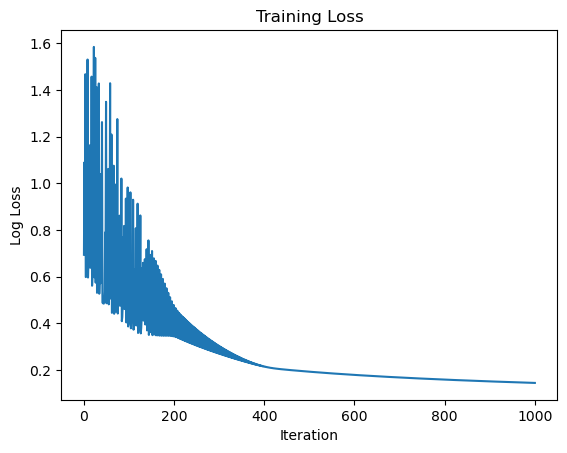

In [ ]:
plt.plot(loss)
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
y_pred = (p >= 0.5).astype(int)
print(p)
print(y_pred)

[[0.01023316]
 [0.03965869]
 [0.14159306]
 [0.39717171]
 [0.72463962]
 [0.91312886]
 [0.97673598]
 [0.99407225]]
[[0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]]
